In [1]:
import matplotlib.pyplot as plt
from glob import glob
import matplotlib.patches as mpatches
# import cosima_cookbook as cc
import numpy as np
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mticker
import cmocean.cm as cm
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cft
import gc
from scipy.interpolate import griddata
from matplotlib import ticker
import scipy.io as sio
# import seawater as sw
import gsw
import seaborn as sns
import matplotlib.patheffects as pe
from scipy import stats
import matplotlib.patheffects as mpe
from tqdm import tqdm

In [2]:
def argnear(dat,val,how_many=1):
    dif = np.abs(dat-val)
    idx = np.argsort(dif)
    return idx[:how_many]

In [3]:
# Set figures properties
# sns.set_style('whitegrid')
# sns.reset_orig()
plt.rcParams['font.size'] = 12
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

## Importing ERA5

In [4]:
path_u = '/g/data/rt52/era5/single-levels/reanalysis/10u/'
path_v = '/g/data/rt52/era5/single-levels/reanalysis/10v/'
year   = np.arange(1993,2020,1)

files_u, files_v = np.array([]), np.array([])
## The files are in different directories
for i in range(len(year)):
    file_u, file_v = glob(path_u + str(year[i]) + '/*'), glob(path_v + str(year[i]) + '/*')
    
    file_u.sort()
    file_v.sort()
    
    files_u  = np.append(files_u, file_u)
    files_v  = np.append(files_v, file_v)

In [5]:
from functools import partial
def _preprocess(ds, lon_bnds, lat_bnds):
    return ds.sel(longitude = lon_bnds, latitude = lat_bnds)

yt_sel = slice(-30.5, -51)
xt_sel = slice(8, 76)
partial_func = partial(_preprocess, lon_bnds=xt_sel, lat_bnds=yt_sel) 

In [6]:
data_u  = xr.open_mfdataset(list(files_u), preprocess=partial_func)  
data_v  = xr.open_mfdataset(list(files_v), preprocess=partial_func)  

In [7]:
time_sel   = slice('1993-01-01', '2019-05-31')

u_atm       = data_u.u10.sel(time=time_sel)
u_atm_daily = u_atm.resample(time='1D').mean('time').compute()
##############################################################
v_atm       = data_v.v10.sel(time=time_sel)
v_atm_daily = v_atm.resample(time='1D').mean('time').compute()

In [8]:
lon_ERA5, lat_ERA5 = u_atm.longitude, u_atm.latitude
LON_ERA5, LAT_ERA5 = np.meshgrid(lon_ERA5, lat_ERA5)

f      = gsw.f(lat_ERA5)
ro_0   = 1025
Dc     = 15*1e-4  #Benoit
ro_air = 1.2928
tau_x  = Dc*ro_air*np.sqrt(u_atm_daily**2 + v_atm_daily**2)*u_atm_daily
tau_y  = Dc*ro_air*np.sqrt(u_atm_daily**2 + v_atm_daily**2)*v_atm_daily
##############################################################
[trash,dlonx] = np.gradient(LON_ERA5)
dx            = dlonx*np.cos(LAT_ERA5*np.pi/180)*111195.
[dlaty,trash] = np.gradient(LAT_ERA5)
dy            = dlaty*111195.
##############################################################
tau_x_dy = np.gradient(tau_x, axis = 1)
tau_y_dx = np.gradient(tau_y, axis = 2)

In [9]:
curl_wind = np.array([tau_y_dx[t]/dx - tau_x_dy[t]/dy for t in range(len(tau_x_dy))])

## Trend



In [10]:
slope   = np.random.rand(len(lat_ERA5), len(lon_ERA5))*np.nan
p_value = slope.copy()

t = np.arange(len(curl_wind))
for i in range(len(lat_ERA5)):
    for j in range(len(lon_ERA5)):
        slope[i,j], intercept, c_value, p_value[i,j], _ = stats.linregress(t, curl_wind[:,i,j])

slope_decade = slope*(365*10 + 2)

In [11]:
## saving this trend
ds = xr.Dataset(data_vars=dict(slope_decade_wsc = (["latitude", "longitude"], slope_decade),
                               p_value_wsc      = (["latitude", "longitude"], p_value)),
                        
                coords=dict(latitude=(["latitude"], lat_ERA5.data),
                            longitude=(["longitude"], lon_ERA5.data)))

path_save = '/g/data/jk72/fs3401/Desktop/Agulhas_meander/output/'
ds.to_netcdf(path_save+'wsc_trend_26years.nc')

## Frontal position

In [12]:
path = '/g/data/v45/fs3401/AmelieMeyer_Agulhas_meander/data/'
data_meander   = glob(path + 'altimetry_meander_location_daily_1993_2019_3m_30thrs.mat')
# data_bathy      = glob(path + 'GMRTv3_7_20200805topo_standing_meander.grd')
lon_boundaries = glob(path + 'meander_regions_lat_lon.mat')

meander_var = sio.loadmat(data_meander[0])
lon_front  = meander_var['meand_lon'][:,0]
lat_front = meander_var['meand_loc_lat'].T
front_boundary = argnear(lon_front, 65)[0]
lon_front      = lon_front[:front_boundary]
lat_front      = lat_front[:,:front_boundary]
###################################################################
# lat_front_mean = np.nanmean(lat_front[12*13:12*14], axis = 0) ## for 2006
# lat_front_mean = np.nanmean(lat_front[12*15:12*16], axis = 0) ## for 2008
lat_front_mean = np.nanmean(lat_front, axis = 0) ## for 2010

/jobfs/171702813.gadi-pbs/ipykernel_1004138/2125619526.py:15: RuntimeWarning: Mean of empty slice
  lat_front_mean = np.nanmean(lat_front, axis = 0) ## for 2010


In [13]:
lat_crest_1, lon_crest_1   = -40.5, 25.3
lat_crest_2, lon_crest_2   = -40.4, 31
lat_crest_4, lon_crest_4   = -41.5, 52.3
lat_crest_7, lon_crest_7   = -44.3, 62.3
############### TROUGHS
lat_trough_1, lon_trough_1 = -38.2, 27.8
lat_trough_2, lon_trough_2 = -37.7, 32.3
lat_trough_3, lon_trough_3 = -39.5, 38
lat_trough_4, lon_trough_4 = -39.5, 50

## Figures

In [14]:
path_fig = '/g/data/jk72/fs3401/Desktop/Agulhas_meander/figures/'
props = dict(boxstyle='round', facecolor='w')
grd = GridSpec(100,100)

extent = [19.99, 65.01, -47, -30.5]
props = dict(boxstyle='round', facecolor='w', alpha=1)
outline = mpe.withStroke(linewidth=2, foreground='w')
ft, color_ = 8, 'w'

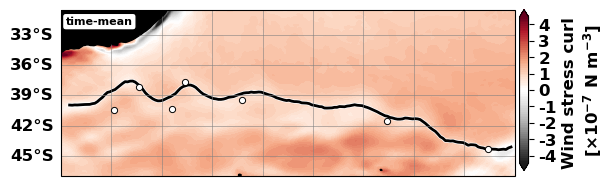

In [15]:
fig = plt.figure(figsize = (9,7))

####################### FIGURE 1
ax = [fig.add_subplot(grd[:31,:], projection=ccrs.PlateCarree())]

cf1 = ax[0].contourf(lon_ERA5, lat_ERA5, np.nanmean(curl_wind, axis = 0)*1e7, levels= np.arange(-4,4.1,.1), cmap='RdGy_r', extend='both')

####################################### Details
for i in range(len(ax)):
    # ax[i].contour(bathy.xt_ocean, bathy.yt_ocean, bathy, levels=np.arange(0,8000,2000), colors='k', linewidths=.3)
    ax[i].plot(lon_front, lat_front_mean, color = 'w', linewidth = 3)
    ax[i].plot(lon_front, lat_front_mean, color = 'k', linewidth = 2)

    ## Scatter
    ax[i].scatter(lon_crest_1, lat_crest_1, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_crest_2, lat_crest_2, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_crest_4, lat_crest_4, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_crest_7, lat_crest_7, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_1, lat_trough_1, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_2, lat_trough_2, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    ax[i].scatter(lon_trough_3, lat_trough_3, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    # ax[i].scatter(lon_trough_4, lat_trough_4, s = 20, color = 'w', edgecolor = 'k', zorder = 50, linewidth=.7)
    
    ax[i].set_extent(extent, ccrs.PlateCarree())
    ax[i].add_feature(cartopy.feature.COASTLINE)
    ax[i].add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
    gl = ax[i].gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.4, color='grey')
    gl.left_labels = True
    gl.ylocator = mticker.FixedLocator(np.arange(-60, -30, 3))
    gl.xlocator = mticker.FixedLocator(np.arange(10, 80, 5))
    gl.ylabel_style = {'size': 12}
    if i == 1:
        gl.bottom_labels = True
        gl.xlabel_style = {'size': 12}

ax[0].annotate(text='time-mean', color='k', xy=(20.5,-32), xycoords='data', bbox=props, fontsize = 8, zorder = 300)
# Colorbar
bar = plt.axes([0.77, 0.65, 0.01, 0.23])
cbar = plt.colorbar(cf1, cax = bar, format = '%.0f')  
cbar.set_label('Wind stress curl \n' + r'[$\times10^{-7}$ N m$^{-3}$]', fontsize = 12) 

# ax[0].set_title('1993–2019', fontsize = 12)

plt.savefig(path_fig + 'Fig_S5.jpg', dpi =300, bbox_inches = 'tight')

## Old version

  hatch.collections[0].set_edgecolor('grey')

  hatch.collections[0].set_linewidth(0)



Text(0.5, 1.0, '1993–2019')

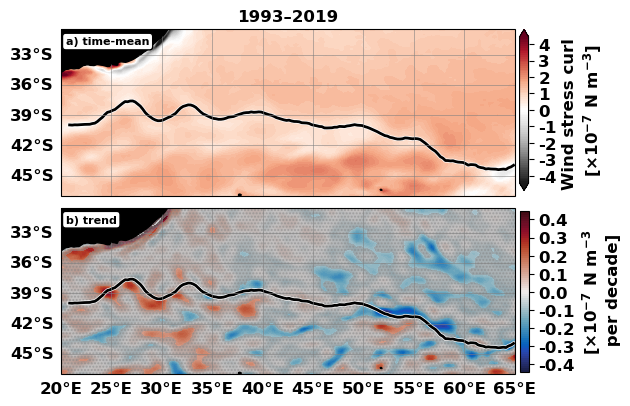

In [29]:
fig = plt.figure(figsize = (9,7))

####################### FIGURE 1
ax = [fig.add_subplot(grd[:31,:], projection=ccrs.PlateCarree()),
      fig.add_subplot(grd[33:64,:], projection=ccrs.PlateCarree())]

cf1 = ax[0].contourf(lon_ERA5, lat_ERA5, np.nanmean(curl_wind, axis = 0)*1e7, levels= np.arange(-4,4.1,.1), cmap='RdGy_r', extend='both')
cf2 = ax[1].contourf(lon_ERA5, lat_ERA5, slope_decade*1e7, levels= np.arange(-.40,.41,.01), cmap=cm.balance)
hatch = ax[1].contourf(lon_ERA5, lat_ERA5, p_value, [0.05,1], cmap='Greys',alpha=.5, hatches=['.....']) 
hatch.collections[0].set_edgecolor('grey')
hatch.collections[0].set_linewidth(0)   

####################################### Details
for i in range(len(ax)):
    # ax[i].contour(bathy.xt_ocean, bathy.yt_ocean, bathy, levels=np.arange(0,8000,2000), colors='k', linewidths=.3)
    ax[i].plot(lon_front, lat_front_mean, color = 'w', linewidth = 3)
    ax[i].plot(lon_front, lat_front_mean, color = 'k', linewidth = 2)
    
    ax[i].set_extent(extent, ccrs.PlateCarree())
    ax[i].add_feature(cartopy.feature.COASTLINE)
    ax[i].add_feature(cartopy.feature.LAND, facecolor='k', zorder=10)
    gl = ax[i].gridlines(draw_labels = False, crs=ccrs.PlateCarree(), linewidth=0.4, color='grey')
    gl.left_labels = True
    gl.ylocator = mticker.FixedLocator(np.arange(-60, -30, 3))
    gl.xlocator = mticker.FixedLocator(np.arange(10, 80, 5))
    gl.ylabel_style = {'size': 12}
    if i == 1:
        gl.bottom_labels = True
        gl.xlabel_style = {'size': 12}

ax[0].annotate(text='a) time-mean', color='k', xy=(20.5,-32), xycoords='data', bbox=props, fontsize = 8, zorder = 300)
ax[1].annotate(text='b) trend', color='k', xy=(20.5,-32), xycoords='data', bbox=props, fontsize = 8, zorder = 300)
# ax[1].annotate(text=r'b) |$\nabla$SST|', color='k', xy=(20.5,-32.5), xycoords='data', bbox=props, fontsize = 10, zorder = 300)
# ax[2].annotate(text='c) Wind speed', color='k', xy=(20.5,-32.5), xycoords='data', bbox=props, fontsize = 10, zorder = 300)
# Colorbar
bar = plt.axes([0.77, 0.65, 0.01, 0.23])
cbar = plt.colorbar(cf1, cax = bar, format = '%.0f')  
cbar.set_label('Wind stress curl \n' + r'[$\times10^{-7}$ N m$^{-3}$]', fontsize = 12) 

bar = plt.axes([0.77, 0.39, 0.01, 0.23])
cbar = plt.colorbar(cf2, cax = bar, format = '%.1f')  
cbar.set_label(r'[$\times10^{-7}$ N m$^{-3}$' + '\n per decade]') 

ax[0].set_title('1993–2019', fontsize = 12)

# plt.savefig(path_fig + 'Fig_S5.jpg', dpi =300, bbox_inches = 'tight')